# Seis bombas nucleares bajo una montaña. La última fue en 2017. La montaña sigue temblando

1.399 sismos en 17 años alrededor del sitio de pruebas de Punggye-ri. El 95,7% ocurrió *después* de la última explosión. ¿No debería haberse calmado?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Fan et al. (2026). *Nuclear tests at Mt. Mantap have reactivated intraplate faults*. **Science** 393(6817):1209-1212.
DOI: [10.1126/science.adx5917](https://doi.org/10.1126/science.adx5917) · Datos en [Zenodo](https://doi.org/10.5281/zenodo.22678084)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-17-mt-mantap-pruebas-nucleares-fallas/notebook.ipynb)

**Video:** pendiente

## Qué midieron

Entre 2006 y 2017, Corea del Norte detonó seis bombas nucleares bajo el monte Mantap, en el sitio de pruebas de Punggye-ri. La sexta y última, el 3 de septiembre de 2017, produjo una señal sísmica equivalente a un terremoto de magnitud 6,3 y deformó la cima unos 3 metros (según el resumen editorial de *Science*).

La expectativa clásica: una explosión subterránea genera una ráfaga breve de sismos que decae en semanas o meses, como las réplicas de un terremoto. El equipo de Fan y colegas quiso comprobarlo con paciencia. Tomaron 17 años de registros sísmicos continuos (2008-2025), buscaron sismos pequeños usando otros sismos como plantilla (*matched-filter*, un método que detecta señales parecidas a las ya conocidas) y construyeron un catálogo de 1.399 sismos locales, de los cuales 955 pudieron relocalizar con precisión (*hypoDD*, un método que ajusta posiciones relativas entre eventos vecinos).

Ojo: el catálogo **no incluye las explosiones**. Son sismos tectónicos — rupturas en fallas de la corteza — en una zona de intraplaca, lejos de cualquier borde entre placas. Las seis explosiones las traemos aparte del catálogo del USGS.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEST6_UTC = '2017-09-03 03:30:01'   # 6.º test nuclear (USGS), el eje antes/después de todo el notebook
TEST6_LAT, TEST6_LON = 41.3324, 129.0297   # epicentro USGS del 6.º test
MC = 1.3                    # magnitud de completitud del paper (ZMAP); por encima de MC el catálogo es completo
DIAS_VENTANA = 365          # ventana antes/después del test para comparar conteos
HORA_NOCHE = (22, 6)        # noche en hora de Corea (KST = UTC+9): 22:00-06:00
FUENTE = 'Fuente: Fan et al. (2026), Science | Datos: Zenodo 10.5281/zenodo.22678084 + USGS ComCat'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'

import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = f'{BASE}/papers/2026-09-17-mt-mantap-pruebas-nucleares-fallas'

# Estilo CaM (local -> fallback GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos (descarga automática si no están en local)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for f in ['sismos_catalogo_inicial.csv', 'sismos_relocalizados.csv',
          'explosiones_nucleares_usgs.csv', 'sismos_historicos_200km.csv']:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{PAPER}/datos/{f}', f'datos/{f}')

s1 = pd.read_csv('datos/sismos_catalogo_inicial.csv', parse_dates=['fecha_hora_utc'])  # Data S1: 1 fila por sismo
s2 = pd.read_csv('datos/sismos_relocalizados.csv', parse_dates=['fecha_hora_utc'])     # Data S2: subconjunto relocalizado
ex = pd.read_csv('datos/explosiones_nucleares_usgs.csv', parse_dates=['fecha_hora_utc'])  # 6 explosiones + colapso (USGS)
hist = pd.read_csv('datos/sismos_historicos_200km.csv')                                  # Table S1: sismos 1424-1810

T6 = pd.Timestamp(TEST6_UTC)
explosiones = ex[ex.tipo == 'explosion'].reset_index(drop=True)

# Coordenadas locales en km respecto al 6.º test (1 grado de longitud se acorta con la latitud)
KM_LAT = 111.32
KM_LON = 111.32 * np.cos(np.radians(41.35))
for df in (s1, s2):
    df['x_km'] = (df.lon_grados - TEST6_LON) * KM_LON
    df['y_km'] = (df.lat_grados - TEST6_LAT) * KM_LAT
    df['dist_km'] = np.hypot(df.x_km, df.y_km)
    df['post_test6'] = df.fecha_hora_utc >= T6
    df['anio'] = df.fecha_hora_utc.dt.year

def es(x, dec=0):
    # formato español: 1.399 / 174,9
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

pre, post = s1[~s1.post_test6], s1[s1.post_test6]
anios_pre = (T6 - s1.fecha_hora_utc.min()).days / 365.25
anios_post = (s1.fecha_hora_utc.max() - T6).days / 365.25
tasa_pre, tasa_post = len(pre) / anios_pre, len(post) / anios_post

print(f'Catálogo inicial: {es(len(s1))} sismos, {s1.fecha_hora_utc.min():%Y-%m-%d} → {s1.fecha_hora_utc.max():%Y-%m-%d}')
print(f'Relocalizados (hypoDD): {es(len(s2))} sismos')
print(f'Explosiones nucleares (USGS): {len(explosiones)}, mb {es(explosiones.mb_usgs.min(), 1)} → {es(explosiones.mb_usgs.max(), 1)}')
print(f'Sismos históricos 1424-1810 (200 km): {len(hist)}, máximo M{es(hist.magnitud.max(), 1)} ({hist.loc[hist.magnitud.idxmax(), "fecha"]})')
print()
print(f'Antes del 6.º test:  {len(pre):>5} sismos en {es(anios_pre, 2)} años → {es(tasa_pre, 1)} por año')
print(f'Después del 6.º test: {len(post):>5} sismos en {es(anios_post, 2)} años → {es(tasa_post, 1)} por año')
print(f'Ratio de tasas después/antes: ×{es(tasa_post / tasa_pre, 1)}  ·  {es(100 * len(post) / len(s1), 1)}% del catálogo es posterior al test')

Catálogo inicial: 1.399 sismos, 2008-07-08 → 2025-05-01
Relocalizados (hypoDD): 955 sismos
Explosiones nucleares (USGS): 6, mb 4,3 → 6,3
Sismos históricos 1424-1810 (200 km): 25, máximo M6,7 (1810/02/19)

Antes del 6.º test:     60 sismos en 9,15 años → 6,6 por año
Después del 6.º test:  1339 sismos en 7,66 años → 174,9 por año
Ratio de tasas después/antes: ×26,7  ·  95,7% del catálogo es posterior al test


## Aquí está.

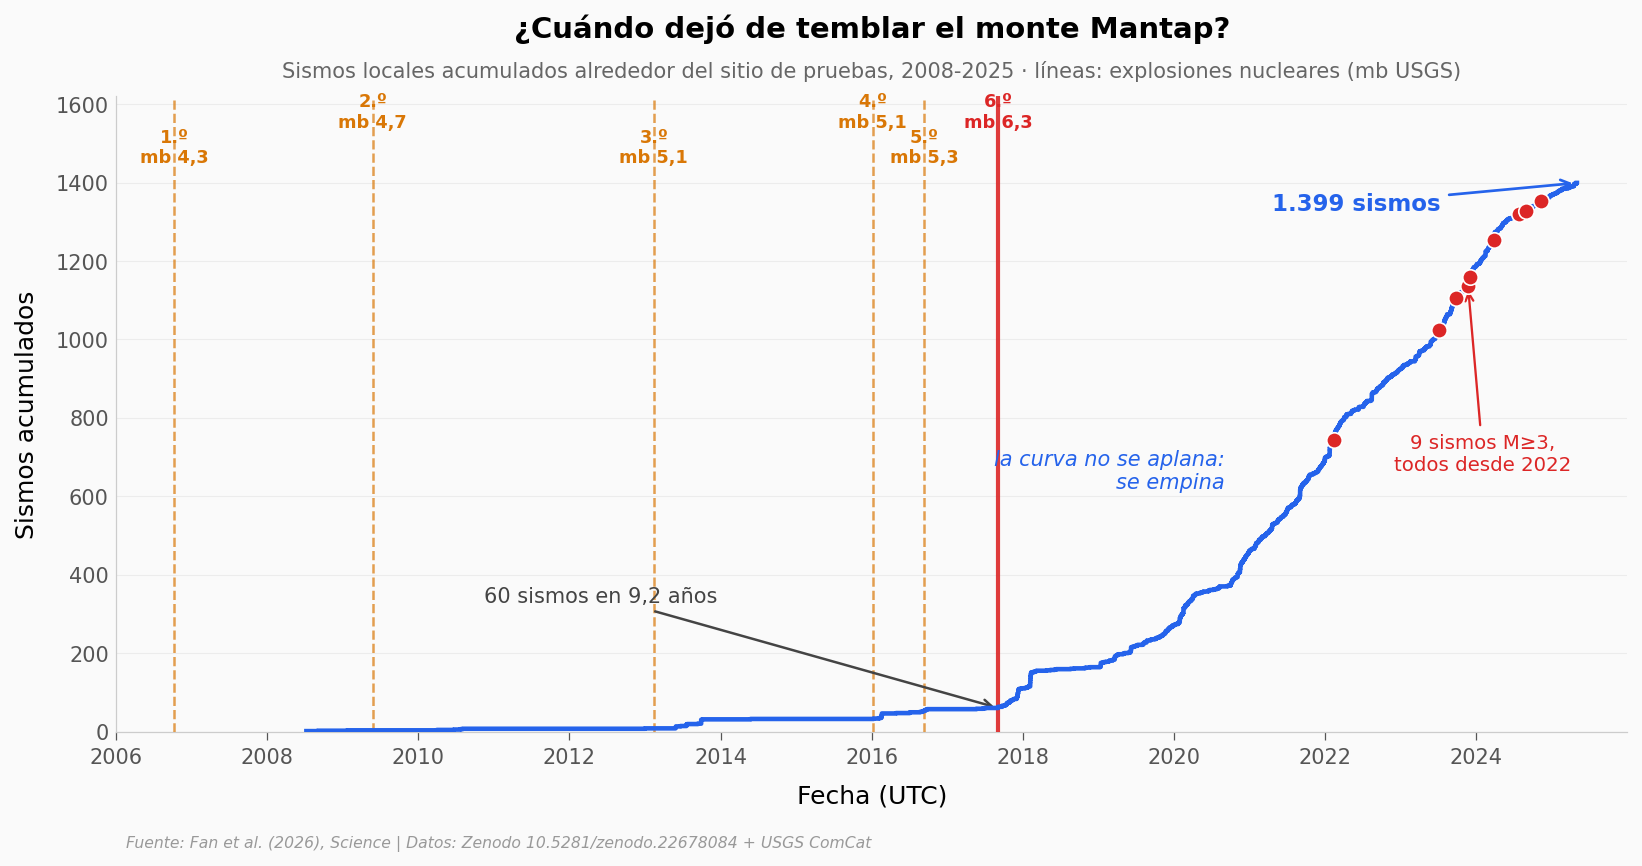

In [2]:
s1s = s1.sort_values('fecha_hora_utc').reset_index(drop=True)
s1s['acumulado'] = np.arange(1, len(s1s) + 1)
grandes = s1s[s1s.magnitud_ml >= 3.0]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.step(s1s.fecha_hora_utc, s1s.acumulado, where='post', color=COLOR_DATOS, linewidth=2.2, zorder=4)

# Las 6 explosiones como líneas verticales; la 6.ª en rojo
for i, r in explosiones.iterrows():
    es6 = (r.orden == '6')
    ax.axvline(r.fecha_hora_utc, color=COLOR_ALERTA if es6 else COLOR_REFERENCIA,
               linewidth=2 if es6 else 1.2, linestyle='-' if es6 else '--', alpha=0.9 if es6 else 0.7, zorder=3)
    y_lab = 1440 if int(r.orden) % 2 else 1530   # escalonar para que 4.º/5.º/6.º no se pisen
    ax.text(r.fecha_hora_utc, y_lab, f'{r.orden}.º\nmb {es(r.mb_usgs, 1)}', fontsize=8.5,
            color=COLOR_ALERTA if es6 else COLOR_REFERENCIA, ha='center', va='bottom', fontweight='bold')

# Sismos M >= 3 sobre la curva
ax.scatter(grandes.fecha_hora_utc, grandes.acumulado, color=COLOR_ALERTA, s=55, zorder=6,
           edgecolors='white', linewidths=0.8)
ax.annotate(f'{len(grandes)} sismos M≥3,\ntodos desde 2022', xy=(grandes.fecha_hora_utc.iloc[3], grandes.acumulado.iloc[3]),
            xytext=(pd.Timestamp('2024-02-01'), 760), fontsize=9.5, color=COLOR_ALERTA, ha='center', va='top',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.1))

# Anotaciones clave
n_pre = int((~s1s.post_test6).sum())
ax.annotate(f'{n_pre} sismos en {es(anios_pre, 1)} años', xy=(T6, n_pre), xytext=(pd.Timestamp('2012-06-01'), 330),
            fontsize=10, color='#444444', ha='center',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.2))
ax.annotate(f'{es(len(s1s))} sismos', xy=(s1s.fecha_hora_utc.iloc[-1], len(s1s)),
            xytext=(pd.Timestamp('2022-06-01'), 1330), fontsize=11, fontweight='bold', color=COLOR_DATOS, ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.3))
ax.text(pd.Timestamp('2020-09-01'), 620, 'la curva no se aplana:\nse empina', fontsize=10, color=COLOR_DATOS,
        ha='right', style='italic')

ax.set_title('¿Cuándo dejó de temblar el monte Mantap?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Sismos locales acumulados alrededor del sitio de pruebas, 2008-2025 · líneas: explosiones nucleares (mb USGS)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Fecha (UTC)')
ax.set_ylabel('Sismos acumulados')
ax.set_ylim(0, 1620)
ax.set_xlim(pd.Timestamp('2006-01-01'), pd.Timestamp('2025-12-31'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sismos_acumulados.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención no es el salto en 2017: es lo que pasa después.

Antes del 6.º test, en 9,15 años, el catálogo tiene 60 sismos: 6,6 por año. Después, en 7,66 años, tiene 1.339: 174,9 por año, una tasa 26,7 veces mayor. Pero una secuencia de réplicas normal se vería como un escalón vertical seguido de una meseta — muchos sismos en los primeros días, luego cada vez menos. Aquí la curva hace lo contrario: arranca despacio y se empina con los años. En 2018 hubo 54 sismos; en 2023, 263. Casi cinco veces más (×4,9), seis años después de la última explosión.

Los nueve sismos de magnitud 3 o más del catálogo (puntos rojos) llegaron todos entre febrero de 2022 y noviembre de 2024. Antes del 6.º test, el mayor sismo registrado fue de magnitud 2,3; después, 3,4.

Un matiz que importa: la tasa "antes" depende de cuántas plantillas tenía el detector para esos años, así que el ×26,7 hay que leerlo como orden de magnitud, no como cifra exacta. El material suplementario reporta que la magnitud de completitud se mantuvo estable (entre 1,2 y 1,4) en todo el periodo, y la tendencia se sostiene si miramos solo los sismos por encima de ese umbral — lo vemos en la siguiente gráfica.

## ¿Más sismos, o mejor detección?

La objeción obvia: quizá el detector simplemente encuentra más sismos pequeños con los años, porque tiene más plantillas. Para descartarlo, contemos solo los sismos de magnitud ≥ 1,3 — el umbral por encima del cual el paper considera el catálogo completo. Y de paso miremos si los sismos también crecen en tamaño.

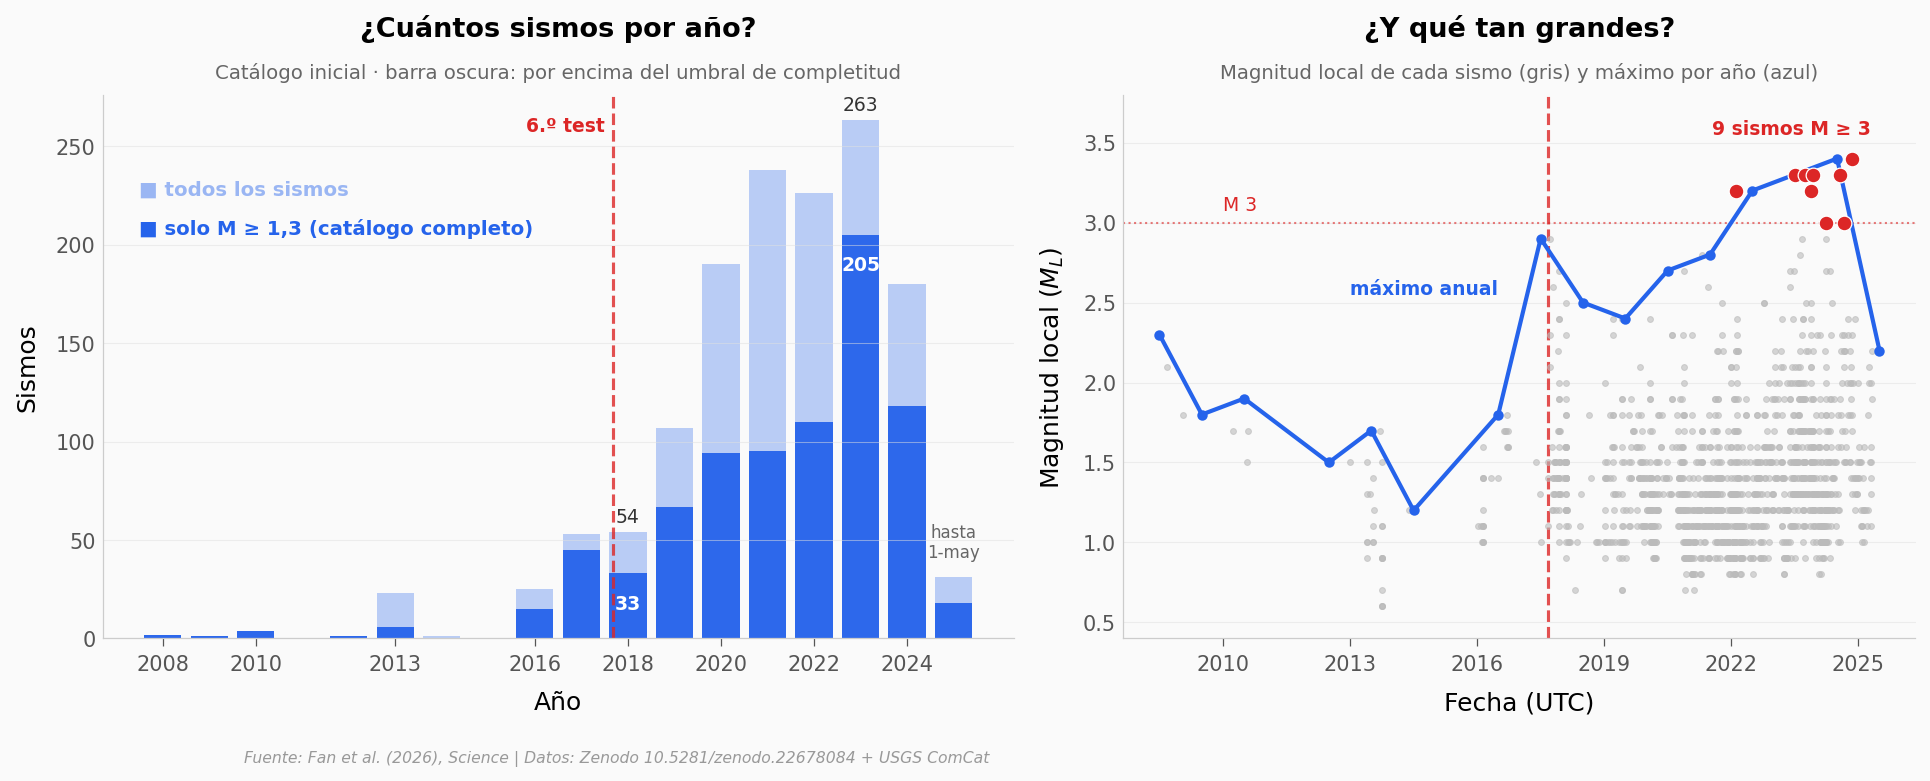

anio        2016  2017  2018   2019   2020   2021   2022   2023   2024  2025
todos       25.0  53.0  54.0  107.0  190.0  238.0  226.0  263.0  180.0  31.0
M ≥ 1,3     15.0  45.0  33.0   67.0   94.0   95.0  110.0  205.0  118.0  18.0
máx. anual   1.8   2.9   2.5    2.4    2.7    2.8    3.2    3.3    3.4   2.2

M ≥ 1,3: 33 sismos en 2018 → 205 en 2023 (×6,2)
Todos:   54 sismos en 2018 → 263 en 2023 (×4,9)
Mayor sismo antes del 6.º test: M2,3 · después: M3,4


In [3]:
por_anio = s1.groupby('anio').size()
por_anio_mc = s1[s1.magnitud_ml >= MC].groupby('anio').size().reindex(por_anio.index, fill_value=0)
mag_max = s1.groupby('anio').magnitud_ml.max()
anios = por_anio.index.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.15, 1]})

# Panel 1: sismos por año, todos vs M >= MC
ax1.bar(anios, por_anio.values, color=COLOR_DATOS, alpha=0.3, width=0.8, label='todos')
ax1.bar(anios, por_anio_mc.values, color=COLOR_DATOS, alpha=0.95, width=0.8, label=f'M ≥ {es(MC, 1)}')
ax1.axvline(2017.67, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.8)
ax1.text(2017.5, por_anio.max() * 0.98, '6.º test', color=COLOR_ALERTA, fontsize=9, ha='right', fontweight='bold')
ax1.text(2025, por_anio[2025] + 8, 'hasta\n1-may', fontsize=8, color='#666666', ha='center', va='bottom')
ax1.text(2007.5, 225, '■ todos los sismos', color=COLOR_DATOS, fontsize=9.5, alpha=0.45, ha='left', fontweight='bold')
ax1.text(2007.5, 205, f'■ solo M ≥ {es(MC, 1)} (catálogo completo)', color=COLOR_DATOS, fontsize=9.5, ha='left', fontweight='bold')
for a in (2018, 2023):
    ax1.text(a, por_anio[a] + 5, str(por_anio[a]), fontsize=9, ha='center', color='#333333')
    ax1.text(a, por_anio_mc[a] - 18, str(por_anio_mc[a]), fontsize=9, ha='center', color='white', fontweight='bold')
ax1.set_title('¿Cuántos sismos por año?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Catálogo inicial · barra oscura: por encima del umbral de completitud',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.set_xlabel('Año')
ax1.set_ylabel('Sismos')
ax1.set_xticks(anios[::2])

# Panel 2: magnitud de cada sismo en el tiempo + máximo anual
ax2.scatter(s1.fecha_hora_utc, s1.magnitud_ml, s=8, color=COLOR_CONTEXTO, alpha=0.6, zorder=3)
g = s1[s1.magnitud_ml >= 3.0]
ax2.scatter(g.fecha_hora_utc, g.magnitud_ml, s=50, color=COLOR_ALERTA, zorder=5, edgecolors='white', linewidths=0.6)
ax2.plot(pd.to_datetime(mag_max.index.astype(str)) + pd.Timedelta(days=182), mag_max.values,
         color=COLOR_DATOS, linewidth=2, marker='o', markersize=4, zorder=4)
ax2.axvline(T6, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.8)
ax2.axhline(3.0, color=COLOR_ALERTA, linewidth=1, linestyle=':', alpha=0.6)
ax2.text(pd.Timestamp('2010-01-01'), 3.05, 'M 3', color=COLOR_ALERTA, fontsize=9, va='bottom')
ax2.text(pd.Timestamp('2013-01-01'), 2.55, 'máximo anual', color=COLOR_DATOS, fontsize=9, fontweight='bold')
ax2.text(pd.Timestamp('2023-06-01'), 3.55, f'{len(g)} sismos M ≥ 3', color=COLOR_ALERTA, fontsize=9, ha='center', fontweight='bold')
ax2.set_title('¿Y qué tan grandes?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Magnitud local de cada sismo (gris) y máximo por año (azul)',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.set_xlabel('Fecha (UTC)')
ax2.set_ylabel('Magnitud local ($M_L$)')
ax2.set_ylim(0.4, 3.8)
ax2.xaxis.set_major_locator(mdates.YearLocator(3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/sismos_por_anio.png', dpi=200, bbox_inches='tight')
plt.show()

tabla = pd.DataFrame({'todos': por_anio, f'M ≥ {es(MC, 1)}': por_anio_mc, 'máx. anual': mag_max}).loc[2016:2025]
print(tabla.T.to_string())
print(f'\nM ≥ {es(MC, 1)}: {por_anio_mc[2018]} sismos en 2018 → {por_anio_mc[2023]} en 2023 (×{es(por_anio_mc[2023] / por_anio_mc[2018], 1)})')
print(f'Todos:   {por_anio[2018]} sismos en 2018 → {por_anio[2023]} en 2023 (×{es(por_anio[2023] / por_anio[2018], 1)})')
print(f'Mayor sismo antes del 6.º test: M{es(pre.magnitud_ml.max(), 1)} · después: M{es(post.magnitud_ml.max(), 1)}')

El aumento sobrevive al filtro: los sismos de magnitud ≥ 1,3 pasan de 33 en 2018 a 205 en 2023 (×6,2). No es un artefacto de detección. El material suplementario del paper llega a la misma conclusión con su propio umbral (*"not driven by improved detection"*). Y las magnitudes también suben: el máximo anual pasa de 2,5 en 2018 a 3,4 en 2024.

El 2025 aparece bajo porque el catálogo termina el 1 de mayo — es un año incompleto, no una caída. El 2024 (180) sí es menor que el 2023 (263); habrá que ver si es ruido o tendencia.

## ¿Dónde tiembla?

El abstract dice que la sismicidad pasó de *difusa* a *organizada espacialmente a lo largo de estructuras controladas por fallas*. Usemos los 955 sismos relocalizados — los que tienen posición fiable — y pongamos el 6.º test en el origen del mapa.

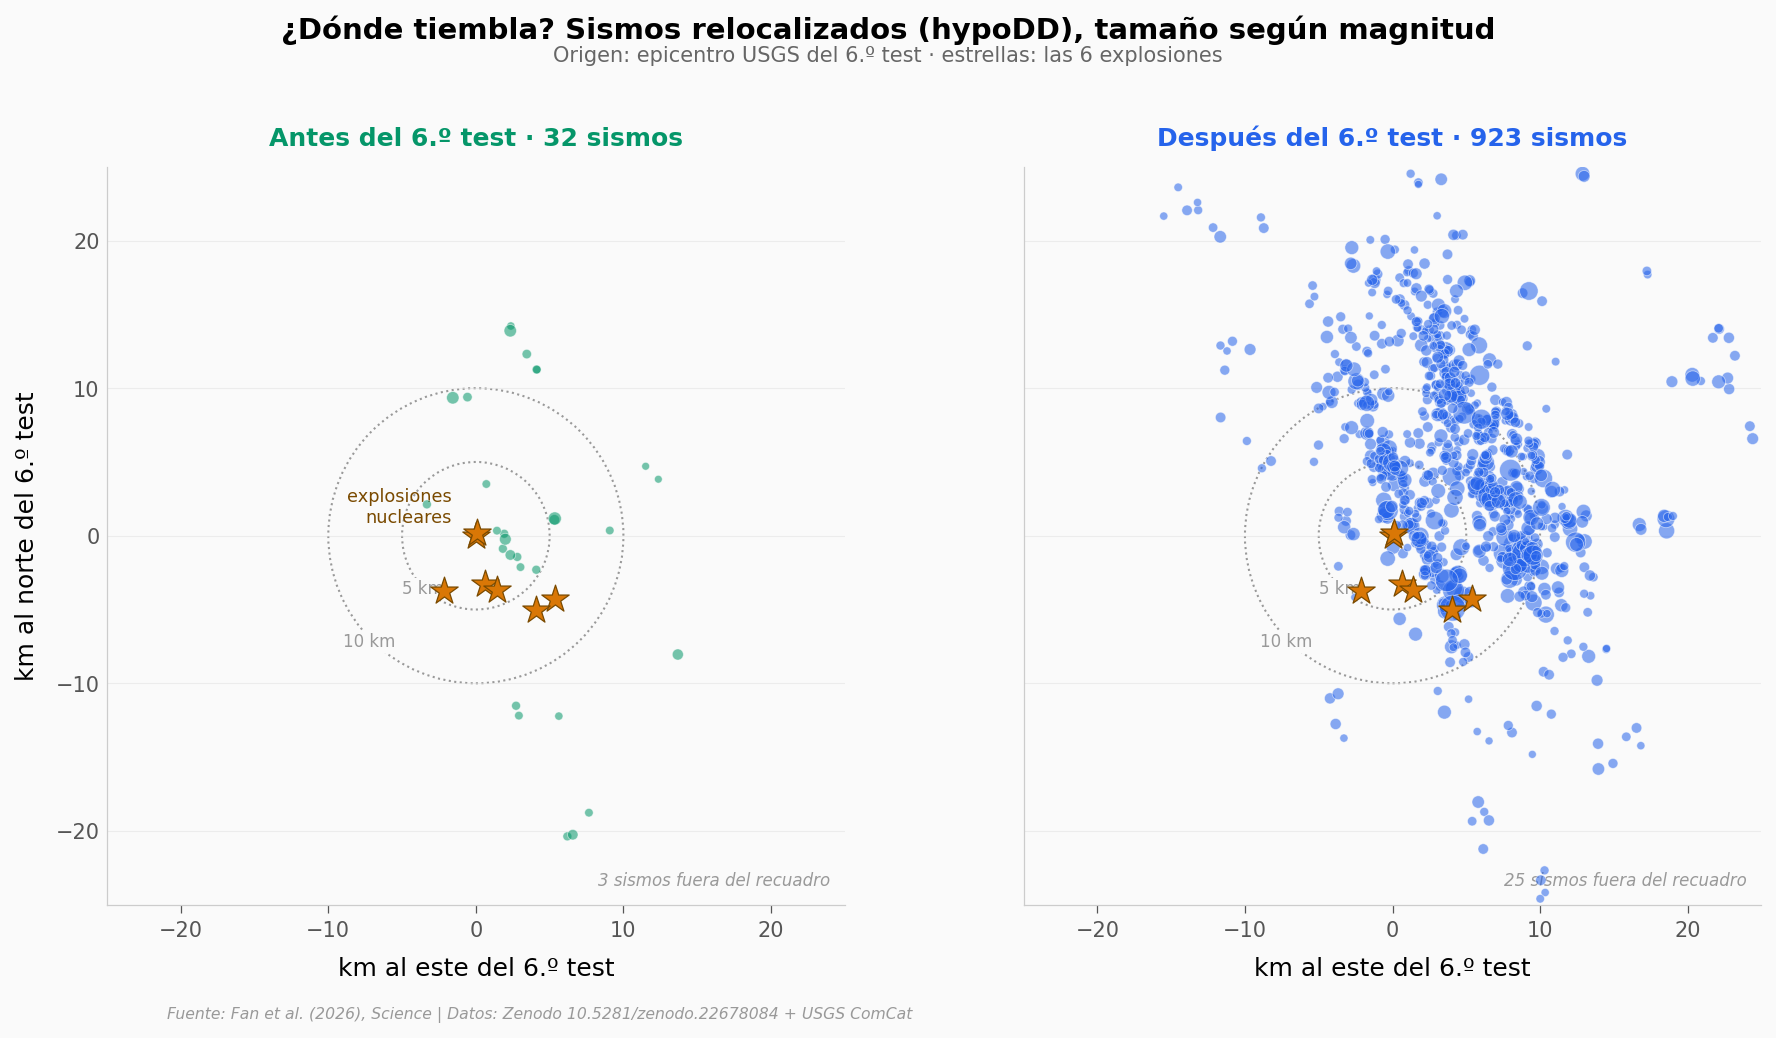

Sismos relocalizados después del test: 923
Distancia al 6.º test: mediana 9,9 km, IQR 6,9-13,1 km, máximo 47,0 km
A ≤ 10 km del test: 52,0%  ·  a ≤ 5 km: 15,2%
Orientación de la nube post-test (PCA) según el radio considerado:
  ≤ 5 km  : n = 140, eje mayor a 154° (NNW-SSE), elongación 1,7
  ≤ 10 km : n = 480, eje mayor a 144° (NNW-SSE), elongación 1,4
  ≤ 15 km : n = 762, eje mayor a 156° (NNW-SSE), elongación 1,6
  todos   : n = 923, eje mayor a 161° (NNW-SSE), elongación 1,8
Sismos relocalizados entre tests: 3.º→4.º 12 · 4.º→5.º 18 · 5.º→6.º 2


In [4]:
r_pre, r_post = s2[~s2.post_test6], s2[s2.post_test6]
ex['x_km'] = (ex.lon_grados - TEST6_LON) * KM_LON
ex['y_km'] = (ex.lat_grados - TEST6_LAT) * KM_LAT
LIM = 25  # km

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharex=True, sharey=True)
for ax, df, titulo, color in [(axes[0], r_pre, f'Antes del 6.º test · {len(r_pre)} sismos', COLOR_SECUNDARIO),
                              (axes[1], r_post, f'Después del 6.º test · {len(r_post)} sismos', COLOR_DATOS)]:
    ax.scatter(df.x_km, df.y_km, s=14 + 18 * (df.magnitud_ml - 0.6) ** 2, color=color, alpha=0.55,
               edgecolors='white', linewidths=0.4, zorder=4)
    ax.scatter(ex.x_km, ex.y_km, marker='*', s=190, color=COLOR_REFERENCIA, edgecolors='#7a4a00', linewidths=0.6, zorder=6)
    for rad in (5, 10):
        ax.add_patch(plt.Circle((0, 0), rad, fill=False, color='#999999', linestyle=':', linewidth=1))
        ax.text(-rad * 0.72, -rad * 0.72, f'{rad} km', fontsize=8, color='#999999', ha='center', va='center',
                bbox=dict(facecolor='#FAFAFA', edgecolor='none', pad=1))
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.set_aspect('equal')
    ax.set_title(titulo, fontsize=12, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('km al este del 6.º test')
    fuera = int(((df.x_km.abs() > LIM) | (df.y_km.abs() > LIM)).sum())
    if fuera:
        ax.text(0.98, 0.02, f'{fuera} sismo{"s" if fuera != 1 else ""} fuera del recuadro', transform=ax.transAxes, fontsize=8,
                color='#999999', ha='right', va='bottom', style='italic')
axes[0].set_ylabel('km al norte del 6.º test')
axes[0].text(ex.x_km[5] - 1.6, ex.y_km[5] + 0.6, 'explosiones\nnucleares', fontsize=8.5, color='#7a4a00', ha='right', va='bottom')

fig.suptitle('¿Dónde tiembla? Sismos relocalizados (hypoDD), tamaño según magnitud', fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.0, 'Origen: epicentro USGS del 6.º test · estrellas: las 6 explosiones', ha='center', fontsize=10, color='#666666')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/mapa_relocalizados.png', dpi=200, bbox_inches='tight')
plt.show()

d = r_post.dist_km
print(f'Sismos relocalizados después del test: {len(r_post)}')
print(f'Distancia al 6.º test: mediana {es(d.median(), 1)} km, IQR {es(d.quantile(0.25), 1)}-{es(d.quantile(0.75), 1)} km, máximo {es(d.max(), 1)} km')
print(f'A ≤ 10 km del test: {es(100 * (d <= 10).mean(), 1)}%  ·  a ≤ 5 km: {es(100 * (d <= 5).mean(), 1)}%')
# ¿Tiene la nube una dirección dominante? PCA sobre las coordenadas: eje mayor (azimut desde el norte)
# y elongación = cociente de desviaciones estándar entre eje mayor y menor (1 = nube redonda)
print('Orientación de la nube post-test (PCA) según el radio considerado:')
for radio in (5, 10, 15, None):
    q = r_post if radio is None else r_post[r_post.dist_km <= radio]
    X = np.c_[q.x_km, q.y_km] - np.c_[q.x_km, q.y_km].mean(axis=0)
    w, v = np.linalg.eigh(np.cov(X.T))
    azimut = np.degrees(np.arctan2(v[0, 1], v[1, 1])) % 180
    etiqueta = f'≤ {radio} km' if radio else 'todos'
    print(f'  {etiqueta:<8}: n = {len(q):>3}, eje mayor a {azimut:.0f}° (NNW-SSE), elongación {es(np.sqrt(w[1] / w[0]), 1)}')
print(f'Sismos relocalizados entre tests: 3.º→4.º {int(((s2.fecha_hora_utc >= explosiones.fecha_hora_utc[2]) & (s2.fecha_hora_utc < explosiones.fecha_hora_utc[3])).sum())}'
      f' · 4.º→5.º {int(((s2.fecha_hora_utc >= explosiones.fecha_hora_utc[3]) & (s2.fecha_hora_utc < explosiones.fecha_hora_utc[4])).sum())}'
      f' · 5.º→6.º {int(((s2.fecha_hora_utc >= explosiones.fecha_hora_utc[4]) & (s2.fecha_hora_utc < T6)).sum())}')

Antes de 2017 el mapa está casi vacío: 32 sismos relocalizados en nueve años, repartidos por ventanas — 12 tras el 3.º test, 18 tras el 4.º, 2 tras el 5.º. El primero de todos apareció el 27 de mayo de 2013, 14,9 semanas después del 3.º test. Actividad intermitente, ligada a cada explosión, que se apaga.

Después de 2017 la nube se llena — 923 sismos — y no se pega a la explosión: solo el 15,2% cae a 5 km o menos del 6.º test, y apenas la mitad (52,0%) a 10 km o menos. La mediana está a 9,9 km (IQR 6,9-13,1). La montaña no tiembla *en* el punto de la explosión: tiembla alrededor.

Los autores identifican en esa nube dos lineaciones orientadas NNW (segmentos este y oeste) que interpretan como fallas reactivadas. Con los datos de este notebook solo podemos hacer una comprobación gruesa: un análisis de componentes principales sobre la nube post-2017 devuelve un eje mayor orientado entre 144° y 161° (NNW-SSE) según el radio, con elongación entre 1,4 y 1,8. Compatible en dirección con lo que describen, pero una nube apenas alargada no es lo mismo que dos fallas: separar los segmentos requiere las secciones y los agrupamientos finos que están en el paper. La estructura se *intuye* en el mapa; aquí queda como lectura de los autores.

## ¿Son sismos "normales"?

Una pregunta razonable: ¿estos sismos se parecen a los sismos tectónicos de cualquier sitio, o tienen alguna firma rara? La forma estándar de responder es la ley de Gutenberg-Richter: en casi cualquier región, por cada sismo de magnitud M hay unas 10 veces más de magnitud M−1. Esa pendiente se llama *valor b* y suele rondar 1.

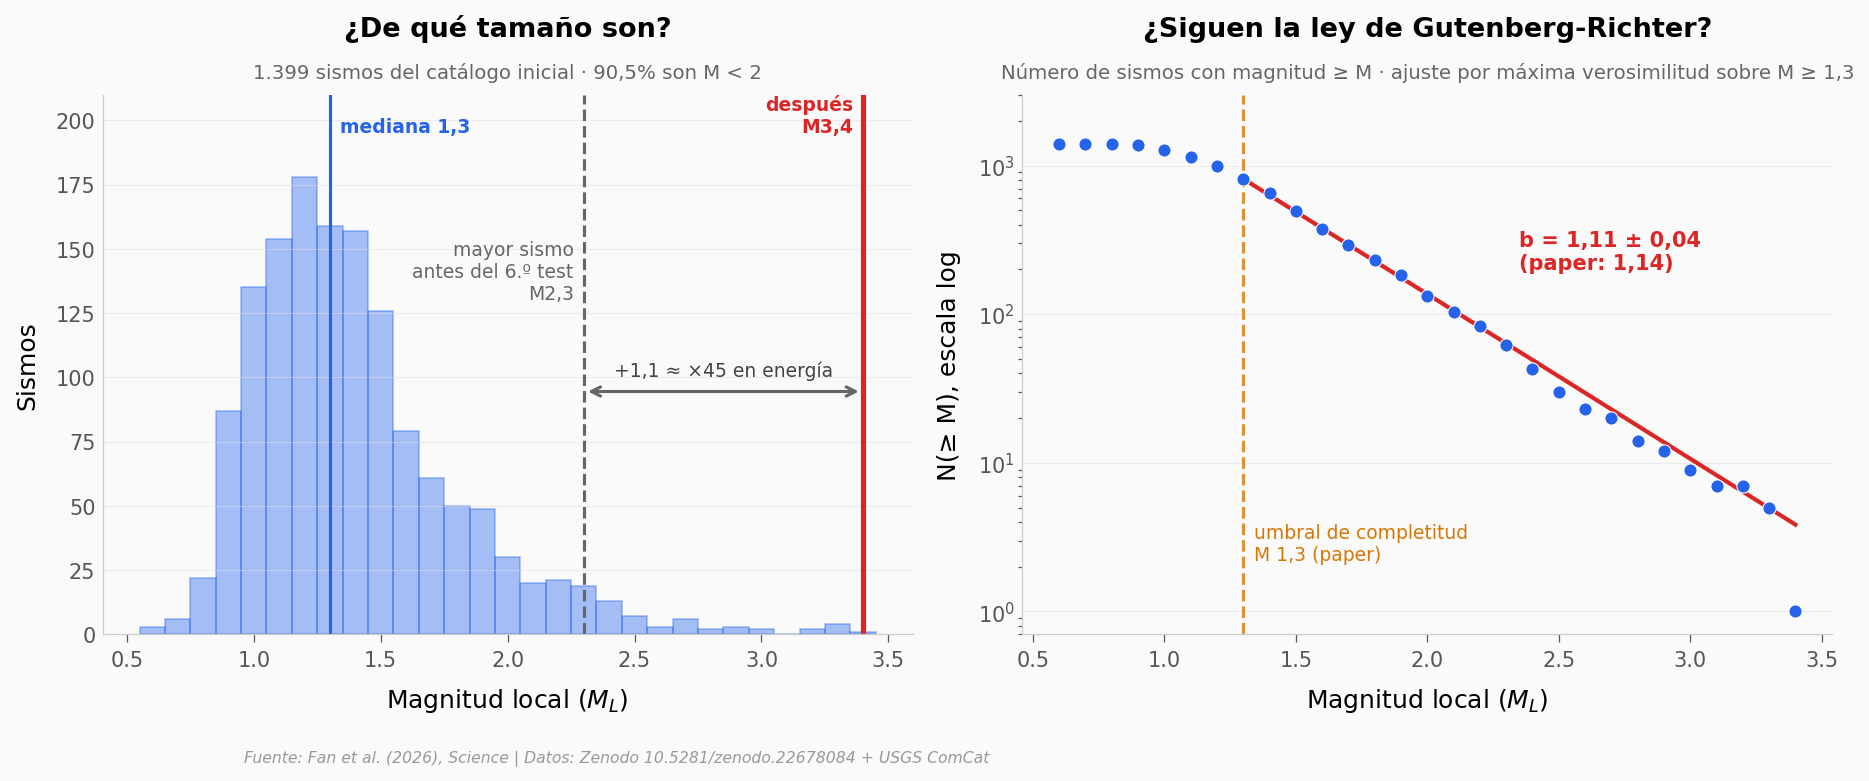

Magnitud: mediana 1,3, IQR 1,1-1,6, media 1,4, máximo 3,4
M < 2: 90,5%  ·  M ≥ 3: 9 sismos
Valor b (Aki, M ≥ 1,3, n = 814): 1,11 ± 0,04   |  paper (ZMAP): 1,14
Magnitud de completitud por máxima curvatura: 1,2   |  paper: 1,3
Del mayor sismo pre-test (M2,3) al mayor post-test (M3,4): ×44,7 en energía liberada


In [5]:
m = s1.magnitud_ml.values
mag_max_pre, mag_max_post = pre.magnitud_ml.max(), post.magnitud_ml.max()

# Gutenberg-Richter: N(>=M) y valor b por máxima verosimilitud (Aki 1965), corrección de bin 0,05
mags_gr = np.round(np.arange(0.6, m.max() + 0.05, 0.1), 1)
n_cum = np.array([(m >= mm - 1e-9).sum() for mm in mags_gr])
m_fit = m[m >= MC - 1e-9]
b = np.log10(np.e) / (m_fit.mean() - (MC - 0.05))
b_se = b / np.sqrt(len(m_fit))
a = np.log10(len(m_fit)) + b * MC
# Magnitud de completitud por máxima curvatura (el bin más poblado)
conteo_bin = pd.Series(np.round(m, 1)).value_counts()
mc_curv = conteo_bin.idxmax()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: histograma de magnitudes
bins = np.round(np.arange(0.55, 3.55, 0.1), 2)
n, _, _ = ax1.hist(m, bins=bins, color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax1.set_ylim(0, y_max)
ax1.axvline(np.median(m), color=COLOR_DATOS, linewidth=1.5)
ax1.text(np.median(m) + 0.04, y_max * 0.93, f'mediana {es(np.median(m), 1)}', color=COLOR_DATOS, fontsize=9, fontweight='bold')
ax1.axvline(mag_max_pre, color='#666666', linewidth=1.5, linestyle='--')
ax1.text(mag_max_pre - 0.04, y_max * 0.62, f'mayor sismo\nantes del 6.º test\nM{es(mag_max_pre, 1)}', color='#666666', fontsize=9, ha='right')
ax1.axvline(mag_max_post, color=COLOR_ALERTA, linewidth=2.5)
ax1.text(mag_max_post - 0.04, y_max * 0.93, f'después\nM{es(mag_max_post, 1)}', color=COLOR_ALERTA, fontsize=9, ha='right', fontweight='bold')
energia = 10 ** (1.5 * (mag_max_post - mag_max_pre))
ax1.annotate('', xy=(mag_max_post, y_max * 0.45), xytext=(mag_max_pre, y_max * 0.45),
             arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax1.text((mag_max_pre + mag_max_post) / 2, y_max * 0.47, f'+{es(mag_max_post - mag_max_pre, 1)} ≈ ×{es(energia)} en energía',
         fontsize=9, color='#444444', ha='center', va='bottom')
ax1.set_title('¿De qué tamaño son?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, f'{es(len(m))} sismos del catálogo inicial · {es(100 * (m < 2).mean(), 1)}% son M < 2',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.set_xlabel('Magnitud local ($M_L$)')
ax1.set_ylabel('Sismos')

# Panel 2: Gutenberg-Richter
ax2.scatter(mags_gr, n_cum, color=COLOR_DATOS, s=40, zorder=5, edgecolors='white', linewidths=0.5)
xx = np.linspace(MC, m.max(), 50)
ax2.plot(xx, 10 ** (a - b * xx), color=COLOR_ALERTA, linewidth=2, zorder=4)
ax2.axvline(MC, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8)
ax2.text(MC + 0.04, 2.2, f'umbral de completitud\nM {es(MC, 1)} (paper)', color=COLOR_REFERENCIA, fontsize=9)
ax2.text(2.35, 200, f'b = {es(b, 2)} ± {es(b_se, 2)}\n(paper: 1,14)', color=COLOR_ALERTA, fontsize=10, fontweight='bold')
ax2.set_yscale('log')
ax2.set_ylim(0.7, 3000)
ax2.set_title('¿Siguen la ley de Gutenberg-Richter?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Número de sismos con magnitud ≥ M · ajuste por máxima verosimilitud sobre M ≥ 1,3',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.set_xlabel('Magnitud local ($M_L$)')
ax2.set_ylabel('N(≥ M), escala log')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/gutenberg_richter.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Magnitud: mediana {es(np.median(m), 1)}, IQR {es(np.percentile(m, 25), 1)}-{es(np.percentile(m, 75), 1)}, media {es(m.mean(), 1)}, máximo {es(m.max(), 1)}')
print(f'M < 2: {es(100 * (m < 2).mean(), 1)}%  ·  M ≥ 3: {int((m >= 3).sum())} sismos')
print(f'Valor b (Aki, M ≥ {es(MC, 1)}, n = {len(m_fit)}): {es(b, 2)} ± {es(b_se, 2)}   |  paper (ZMAP): 1,14')
print(f'Magnitud de completitud por máxima curvatura: {es(mc_curv, 1)}   |  paper: 1,3')
print(f'Del mayor sismo pre-test (M{es(mag_max_pre, 1)}) al mayor post-test (M{es(mag_max_post, 1)}): ×{es(energia, 1)} en energía liberada')

Sí, son sismos normales. Nuestro valor b es 1,11 ± 0,04 (el paper reporta 1,14 con otro software): una pendiente tectónica de manual. El 90,5% de los eventos son de magnitud menor que 2 — imperceptibles para una persona. La mediana es 1,3 (IQR 1,1-1,6). Nada en la distribución de tamaños grita "explosión": lo anómalo no es *cómo* son los sismos, sino *cuántos*, *cuándo* y que sigan aumentando.

Y hay un contexto que el paper trae de los registros históricos coreanos: en un radio de 200 km hubo 25 sismos documentados entre 1424 y 1810, cinco de ellos de magnitud ≥ 5 y uno de 6,7 en 1810. Esta corteza ya rompía sola, con fallas capaces de dar un M6,7, mucho antes de que existiera el sitio de pruebas. El abstract habla de un volumen "críticamente estresado": los autores interpretan que las seis explosiones acumularon daño y redistribuyeron esfuerzos hasta despertar fallas que ya estaban cerca del límite. Ese mecanismo es interpretación; lo que el catálogo mide es la secuencia temporal y la geometría.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La sismicidad persistió y se intensificó durante años tras el 6.º test (2017) | ✅ | 60 sismos antes vs 1.339 después; 6,6 → 174,9 sismos/año (×26,7). 2018 → 2023: 54 → 263 (×4,9). Se sostiene en M ≥ 1,3: 33 → 205 (×6,2) |
| No es una secuencia de réplicas breve: la actividad sostenida empezó 20 días después | ✅ | El 3-sep-2017 hay 3 sismos aislados (M 1,1-1,5; solo 1 relocalizado); luego nada hasta el 23-sep-2017 (M 2,3 / 2,9 / 2,1). El paper lo enmarca como "about 20 days" |
| Antes de 2017 la actividad era intermitente, ligada a cada explosión | ✅ | Relocalizados: 12 tras el 3.º test, 18 tras el 4.º, 2 tras el 5.º (coincide con el suplementario). Primer sismo 14,9 semanas tras el 3.º test |
| Los sismos crecieron en magnitud | ✅ | Máximo pre-test M 2,3; post-test M 3,4. Los 9 sismos M ≥ 3 ocurren entre 2022-02-11 y 2024-11-09 |
| El aumento no se debe a mejor detección | ✅ | La tendencia se mantiene por encima del umbral de completitud (Mc 1,3 según el paper; 1,2 por máxima curvatura). El sesgo de detección nocturna se concentra en los pequeños: 65,1% de noche en M < 1,3 vs 33,9% en M > 1,3 (ver celda experimental) |
| Los sismos siguen Gutenberg-Richter con b ≈ 1,1 | ✅ | b = 1,11 ± 0,04 (Aki MLE, n = 814) vs 1,14 del paper; diferencia del 2,8% |
| La sismicidad se organiza en dos lineaciones NNW controladas por fallas | ⚠️ | El mapa muestra una nube extensa (mediana 9,9 km del test, 52,0% a ≤ 10 km). Un PCA global da eje mayor a 144-161° (NNW-SSE) con elongación 1,4-1,8: compatible en orientación, pero no separa dos lineaciones. Es lectura de los autores con métodos más finos |
| Las fallas son someras y se agrupan bajo topografía asimétrica | ⚠️ | Las profundidades del catálogo no están bien restringidas (el 65,7% del catálogo inicial tiene profundidad fija; el suplementario lo reconoce). No tenemos modelo topográfico ni de esfuerzos: es interpretación del paper |
| Las explosiones *causaron* la reactivación de fallas | ⚠️ | El catálogo muestra asociación temporal fuerte, no un mecanismo. El paper lo formula como "*can drive*, under specific geological conditions" |

> **Limitaciones:** (1) El paper es de acceso restringido (paywall): las comprobaciones vienen del material suplementario y del resumen editorial, no del texto principal. (2) La tasa "antes" depende del pool de plantillas del detector; las tasas pre-2013 son especialmente inciertas. (3) Las profundidades no se pueden usar. (4) Los sismos históricos 1424-1810 vienen de crónicas (intensidad → magnitud), con incertidumbres grandes. (5) Son datos observacionales: sin un sitio de control con la misma geología y sin explosiones, la causalidad es inferencia de los autores. (6) Regla de este Lab: no hay comparación entre grupos experimentales, así que no reportamos tamaños de efecto tipo d de Cohen; los contrastes son tasas y conteos.

## Ahora tú

1. **¿Cada explosión dejó su propia estela?** Cambia `DIAS_VENTANA` y cuenta, para cada una de las 6 explosiones, cuántos sismos hay en la ventana anterior y posterior (`s1.fecha_hora_utc.between(...)`). ¿El 3.º y el 4.º test tienen réplicas y el 1.º y 2.º no? Pista: el catálogo empieza en 2008-07 — el 1.º test (2006) queda fuera.
2. **¿El valor b cambió con el tiempo?** Recalcula `b` con la fórmula de Aki para los sismos antes y después de 2020 (`s1[s1.anio < 2020]`). Ojo con el n: la incertidumbre es `b / sqrt(n)`. ¿La diferencia supera el error?
3. **¿Se acerca o se aleja?** Para los relocalizados posteriores al test, calcula la mediana de `dist_km` por año (`r_post.groupby('anio').dist_km.median()`). ¿La actividad migra hacia afuera con los años, o se queda a la misma distancia?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Tiembla más de noche? Si la montaña no sabe qué hora es, el 33,3% de los sismos
# (8 h de 24) deberían caer entre las 22:00 y las 06:00 de Corea. Veamos por tamaño.
hora_kst = (s1.fecha_hora_utc + pd.Timedelta(hours=9)).dt.hour
noche = (hora_kst >= HORA_NOCHE[0]) | (hora_kst < HORA_NOCHE[1])
esperado = (24 - HORA_NOCHE[0] + HORA_NOCHE[1]) / 24 * 100

pequenos, grandes_m = s1.magnitud_ml < MC, s1.magnitud_ml > MC
print(f'Esperado si el reloj no importa: {es(esperado, 1)}% de noche')
print(f'Sismos M < {es(MC, 1)}:  {es(100 * noche[pequenos].mean(), 1)}% de noche  (n = {int(pequenos.sum())})')
print(f'Sismos M > {es(MC, 1)}:  {es(100 * noche[grandes_m].mean(), 1)}% de noche  (n = {int(grandes_m.sum())})')
print(f'(los {int((s1.magnitud_ml == MC).sum())} sismos de exactamente M {es(MC, 1)} quedan fuera de ambos grupos)')
print()
bordes = [0.5, 1.0, 1.3, 1.6, 2.0, 3.5]
etiq = ['0,6-0,9', '1,0-1,2', '1,3-1,5', '1,6-1,9', '2,0-3,4']
s1['bin_mag'] = pd.cut(s1.magnitud_ml, bins=bordes, labels=etiq, right=False)
frac = s1.groupby('bin_mag', observed=True).apply(lambda g: 100 * noche.loc[g.index].mean())
for k, v in frac.items():
    print(f'  M {k}: {es(v, 1):>5}% de noche  (n = {int((s1.bin_mag == k).sum())})')
print()
print('Lectura: cuanto más pequeño el sismo, más probable es que lo hayamos encontrado de noche,')
print('cuando hay menos ruido humano (tráfico, maquinaria). Por encima de M 1,3 el conjunto (33,9%, n = 655)')
print('ya no se distingue del 33% esperado; el tramo M 1,6-1,9 queda incluso por debajo (24,7%, n = 239) y')
print('el de M ≥ 2 vuelve al 35,3%. La montaña no tiembla más de noche: la oímos mejor.')

Esperado si el reloj no importa: 33,3% de noche
Sismos M < 1,3:  65,1% de noche  (n = 585)
Sismos M > 1,3:  33,9% de noche  (n = 655)
(los 159 sismos de exactamente M 1,3 quedan fuera de ambos grupos)

  M 0,6-0,9:  76,3% de noche  (n = 118)
  M 1,0-1,2:  62,3% de noche  (n = 467)
  M 1,3-1,5:  46,6% de noche  (n = 442)
  M 1,6-1,9:  24,7% de noche  (n = 239)
  M 2,0-3,4:  35,3% de noche  (n = 133)

Lectura: cuanto más pequeño el sismo, más probable es que lo hayamos encontrado de noche,
cuando hay menos ruido humano (tráfico, maquinaria). Por encima de M 1,3 el conjunto (33,9%, n = 655)
ya no se distingue del 33% esperado; el tramo M 1,6-1,9 queda incluso por debajo (24,7%, n = 239) y
el de M ≥ 2 vuelve al 35,3%. La montaña no tiembla más de noche: la oímos mejor.


## Créditos

- **Paper:** Fan, W. et al. (2026). *Nuclear tests at Mt. Mantap have reactivated intraplate faults*. Science 393(6817):1209-1212. DOI: [10.1126/science.adx5917](https://doi.org/10.1126/science.adx5917). Acceso restringido; material suplementario consultado.
- **Datos:** Data S1 (catálogo inicial, 1.399 sismos) y Data S2 (955 relocalizados) del repositorio [Zenodo 10.5281/zenodo.22678084](https://doi.org/10.5281/zenodo.22678084), convertidos a CSV. Explosiones nucleares del catálogo [USGS ComCat](https://earthquake.usgs.gov/earthquakes/search/). Sismos históricos 1424-1810 transcritos de la Table S1 del material suplementario.
- **Código:** [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-17-mt-mantap-pruebas-nucleares-fallas) — MIT.

## Fuentes

**Paper**: [Nuclear tests at Mt. Mantap have reactivated intraplate faults](https://doi.org/10.1126/science.adx5917)  
*Science, 2026-09-17 · paywall*

**Supplementary Material**: [Supplementary Materials for: Nuclear tests at Mt. Mantap have reactivated intraplate faults (Materials and Methods, Figs. S1-S26, Tables S1-S3)](https://www.science.org/doi/suppl/10.1126/science.adx5917/suppl_file/science.adx5917_sm.pdf)  
*Science, 2026-09-17*

**Datos**: [Data for: Nuclear tests at Mt. Mantap have reactivated intraplate faults (Data S1 initial catalog, Data S2 relocated catalog)](https://doi.org/10.5281/zenodo.22678084)  
*Zenodo, 2026-09-09*

**Referencias citadas**: [USGS ComCat: eventos M≥4 a ≤40 km de Punggye-ri, 2006-2017 (explosiones nucleares y colapso)](https://earthquake.usgs.gov/fdsnws/event/1/query?starttime=2006-01-01&endtime=2017-12-31&latitude=41.30&longitude=129.08&maxradiuskm=40&minmagnitude=4&format=csv)

*27 afirmaciones del notebook verificadas contra estas fuentes*